#  DATA ANALYTICS MINI PROJECT
### Author :  REENA SHARON Y
### Created on : 28-10-24
### Dataset: Retail Insights from Superstore Data
### About Dataset: 
#### This Dataset is a CSV file that contains sales data from a company called "Super Store". 
#### It includes information about each order, such as the shipping method, customer segment, location, product category and sub-category, sales amount, quantity, discount, and profit.
#### This data is used to analyze sales trends, customer behavior, and product performance.
#### It consists of 13 columns and 9994 rows

### Student Details:
##### NAME           :REENA SHARON Y
##### COLLEGE        :PANIMALAR ENGINEERING COLLEGE
##### YEAR           :III
##### BRANCH         :ARTIFICIAL INTELLIGENCE AND DATA SCIENCE


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Read the dataset
df = pd.read_csv('1719219914-Analysis of Super Store - DA (1).csv')

# Display basic information
print("Dataset Overview:")
print(df.head())
print("Dataset Info:")
print(df.info())

Dataset Overview:
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2 

In [3]:
df.shape

(9994, 13)

In [9]:
# Set style for better visualizations
#plt.style.use('seaborn')
print(os.listdir())

['1719219914-Analysis of Super Store - DA (1).csv', 'Retail_Insights.ipynb']


In [41]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


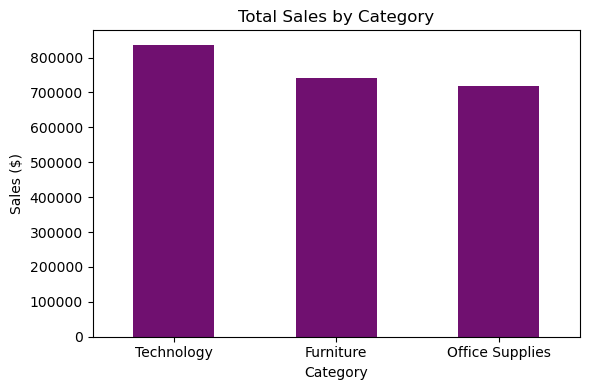

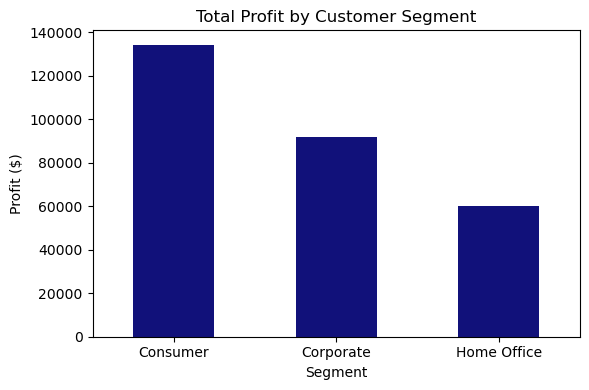

<Figure size 1000x600 with 0 Axes>

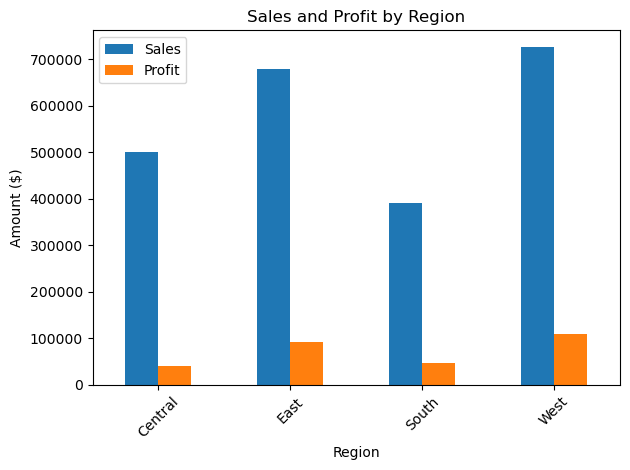

Key Metrics:
Total Sales: $ 2297200.86
Total Profit: $ 286397.02
Overall Profit Margin:  12.47 %


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset
df = pd.read_csv('1719219914-Analysis of Super Store - DA (1).csv')

# Sales by Category
plt.figure(figsize=(6,4))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values,width= 0.5, color= 'purple')
plt.title('Total Sales by Category')
plt.xticks(rotation=0)
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# Profit by Segment
plt.figure(figsize=(6,4))
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=segment_profit.index, y=segment_profit.values,width=0.5, color='darkblue')
plt.title('Total Profit by Customer Segment')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

# Regional Performance
plt.figure(figsize=(10, 6))
regional_sales = df.groupby('Region')[['Sales', 'Profit']].sum()
regional_sales.plot(kind='bar')
plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.legend(['Sales', 'Profit'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate key metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit/total_sales) * 100

print("\Key Metrics:")
print("Total Sales: $", round(total_sales, 2))
print("Total Profit: $", round(total_profit, 2))
print("Overall Profit Margin: ", round(profit_margin, 2), "%")

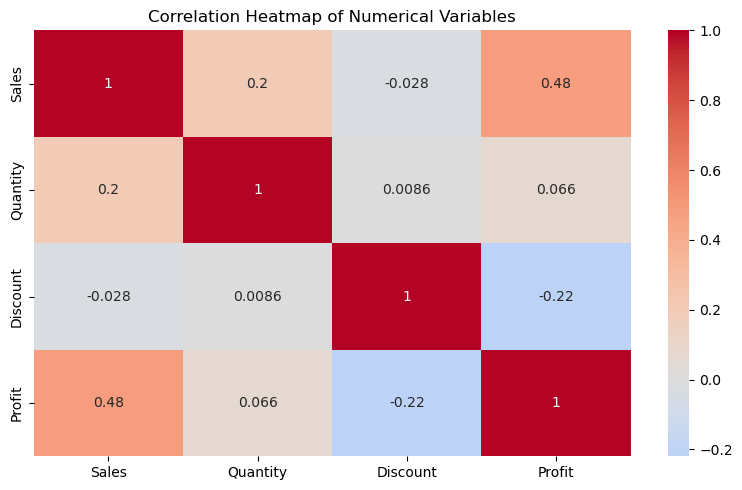

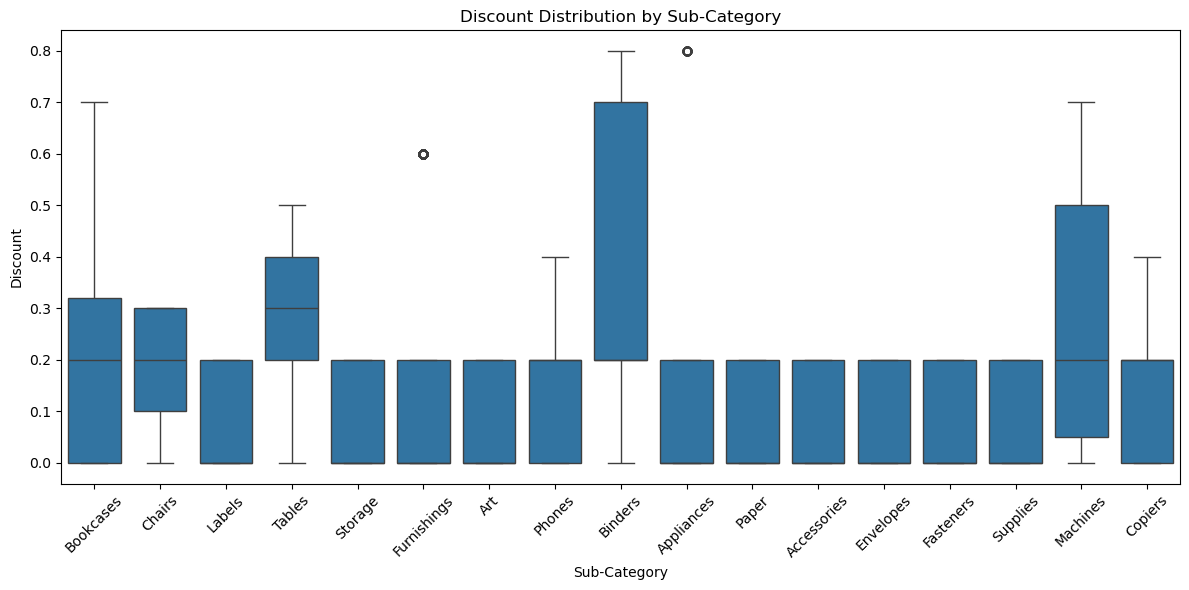

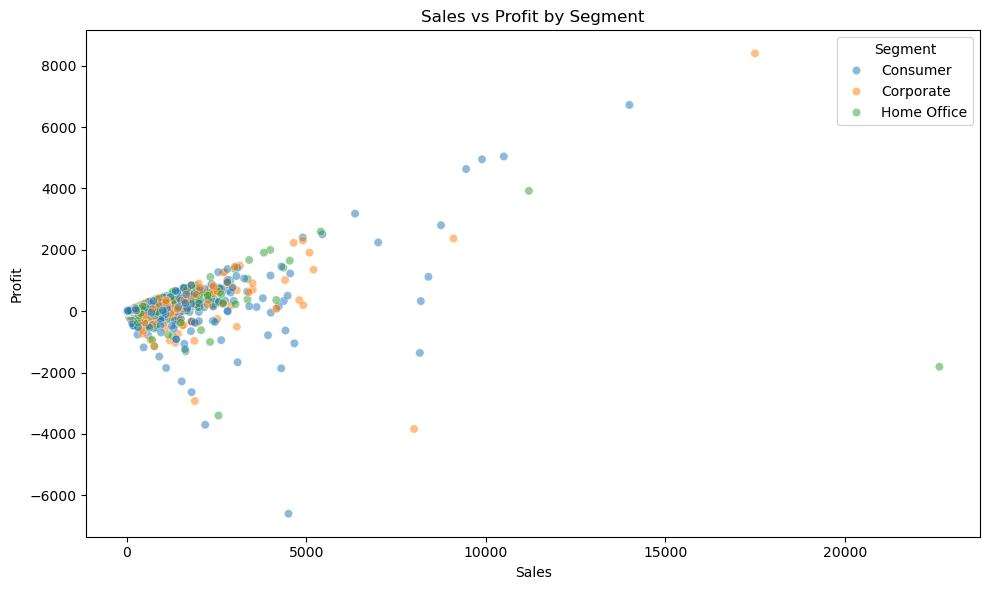

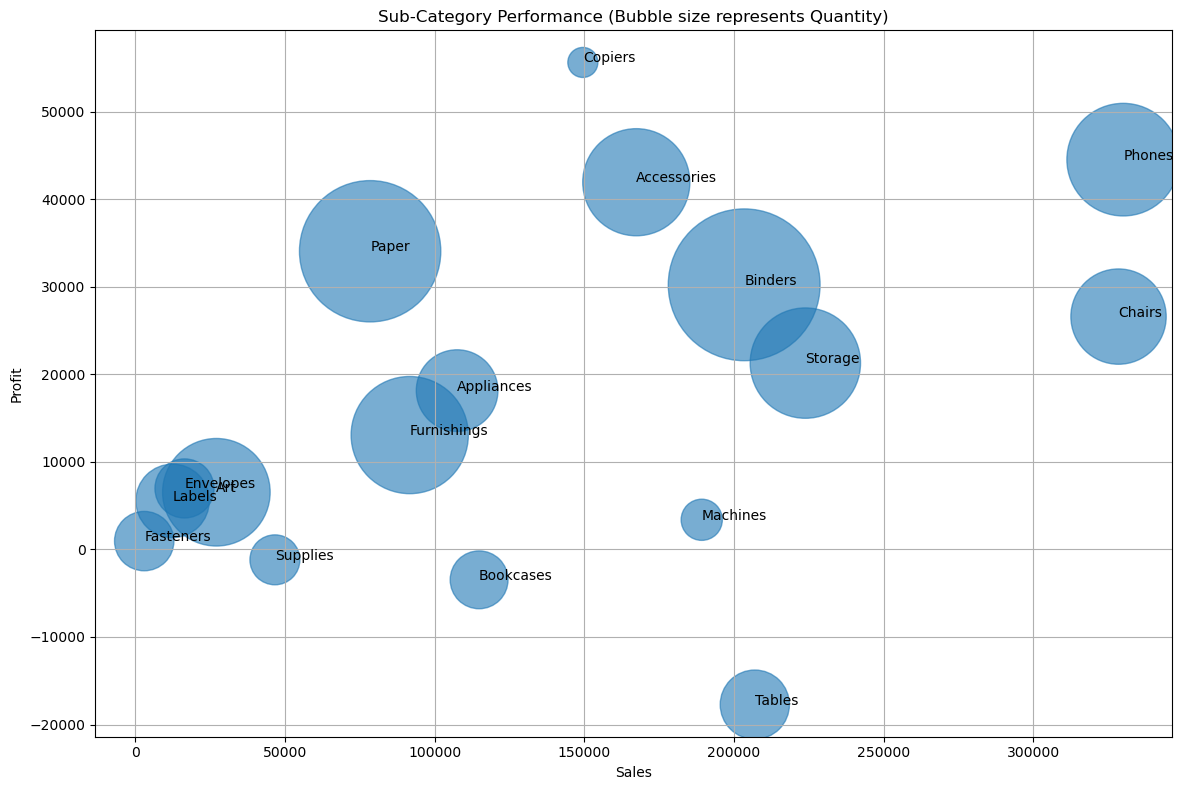

In [40]:
# 1. Correlation Heatmap
plt.figure(figsize=(8,5))
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

# 2. Discount Distribution by Sub-Category
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sub-Category', y='Discount', data=df)
plt.title('Discount Distribution by Sub-Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Sales vs Profit Scatter Plot with Segment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Segment', alpha=0.5)
plt.title('Sales vs Profit by Segment')
plt.tight_layout()
plt.show()

# 4. Sub-Category Performance Bubble Plot
sub_cat_metrics = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(sub_cat_metrics['Sales'], 
           sub_cat_metrics['Profit'],
           s=sub_cat_metrics['Quantity']*2,  # Size based on quantity
           alpha=0.6)

# Annotate points
for i, txt in enumerate(sub_cat_metrics['Sub-Category']):
    plt.annotate(txt, (sub_cat_metrics['Sales'].iloc[i], sub_cat_metrics['Profit'].iloc[i]))

plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sub-Category Performance (Bubble size represents Quantity)')
plt.grid(True)
plt.tight_layout()
plt.show()